# Oscillatory Case 0 solution — Berton (2023) Section 3

This notebook reproduces the oscillatory Case 0 solution (`z_W0 = 9 km`; paper Figures 16–24).

Common simulation conversion and plotting code lives in `cloud_rom.berton2023_plots`. The simulation disables Coriolis to match the paper.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
src = repo / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

from cloud_rom import berton2023 as b
from cloud_rom import berton2023_plots as bp

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

## Run simulation

Increase `SAMPLES` for denser plotted curves; it does not change the integration timestep. The resulting CSV contains plain numeric magnitudes, not Pint quantity strings.

In [2]:
REQUESTED_DURATION_H = 40.0
DT_S = 0.04
SAMPLES = 2400
OSCILLATORY = True

atm = b.atmosphere_for_case(0, oscillatory=OSCILLATORY)
df = bp.run_case0(
    oscillatory=OSCILLATORY,
    duration_h=REQUESTED_DURATION_H,
    dt_s=DT_S,
    samples=SAMPLES,
    include_coriolis=False,
    progress=True,
)
bp.summarize_run(df, requested_duration_h=REQUESTED_DURATION_H)

data = bp.magnitude_frame(df, atm)
csv_path = bp.export_magnitudes(data, repo / "notebooks" / "df_oscillatory_magnitudes.csv")
print(f"Wrote {csv_path}")
data.head()

oscillatory Case 0:   0%|          | 0/3600001 [00:00<?, ?step/s]

Rows: 2401
Last sampled time: 40.000 h (requested 40.000 h)
Last sampled mass: 0.9958 µg
Wrote /home/iross/research/ongoing/ai-class/code/cloud-rom/episodes/01-berton2023-integration/outputs/df_oscillatory_magnitudes.csv


,t_h,x_km,z_km,u_m_s,w_m_s,m_ug,a_um,c_um,cB_um,Di_um,...,dT_mK,Siminus1_pct,R_pct,drive_pct,psi,CD,Re,x_minus_x0_km,z_minus_z0_km,Wf_m_s
0,0.000000,2.000000,10.000000,0.000000,0.600000,0.935543,51.100000,102.200000,20.44,124.764911,...,5.784852,3.103942,0.883524,2.220418,0.800000,11.326126,2.078799,0.000000,0.000000,0.000000
1,0.016667,1.999625,10.002469,-0.012334,0.040283,0.937582,51.138255,102.276511,20.44,124.855484,...,5.705692,3.073859,0.884207,2.189652,0.800150,11.309472,2.082308,-0.000375,0.002469,-0.559717
2,0.033333,1.998525,10.004865,-0.024315,0.039592,0.939595,51.175970,102.351940,20.44,124.944777,...,5.628842,3.044660,0.884881,2.159779,0.800297,11.293050,2.085779,-0.001475,0.004865,-0.560408
3,0.050000,1.996712,10.007220,-0.036090,0.038910,0.941583,51.213151,102.426302,20.44,125.032806,...,5.553283,3.015961,0.885545,2.130416,0.800442,11.276894,2.089205,-0.003288,0.007220,-0.561090
4,0.066667,1.994198,10.009535,-0.047662,0.038237,0.943545,51.249809,102.499618,20.44,125.119597,...,5.478998,2.987755,0.886200,2.101555,0.800585,11.261000,2.092587,-0.005802,0.009535,-0.561763


## Check initial rows

In [3]:
data[["t_h", "x_km", "z_km", "x_minus_x0_km", "z_minus_z0_km", "m_ug", "Re", "CD"]].head(10)

,t_h,x_km,z_km,x_minus_x0_km,z_minus_z0_km,m_ug,Re,CD
0,0.000000,2.000000,10.000000,0.000000,0.000000,0.935543,2.078799,11.326126
1,0.016667,1.999625,10.002469,-0.000375,0.002469,0.937582,2.082308,11.309472
2,0.033333,1.998525,10.004865,-0.001475,0.004865,0.939595,2.085779,11.293050
3,0.050000,1.996712,10.007220,-0.003288,0.007220,0.941583,2.089205,11.276894
4,0.066667,1.994198,10.009535,-0.005802,0.009535,0.943545,2.092587,11.261000
5,0.083333,1.990997,10.011809,-0.009003,0.011809,0.945482,2.095925,11.245362
6,0.100000,1.987119,10.014044,-0.012881,0.014044,0.947395,2.099221,11.229972
7,0.116667,1.982576,10.016240,-0.017424,0.016240,0.949283,2.102474,11.214826
8,0.133333,1.977380,10.018397,-0.022620,0.018397,0.951149,2.105686,11.199918
9,0.150000,1.971543,10.020516,-0.028457,0.020516,0.952990,2.108857,11.185243


## Trajectory and hodograph

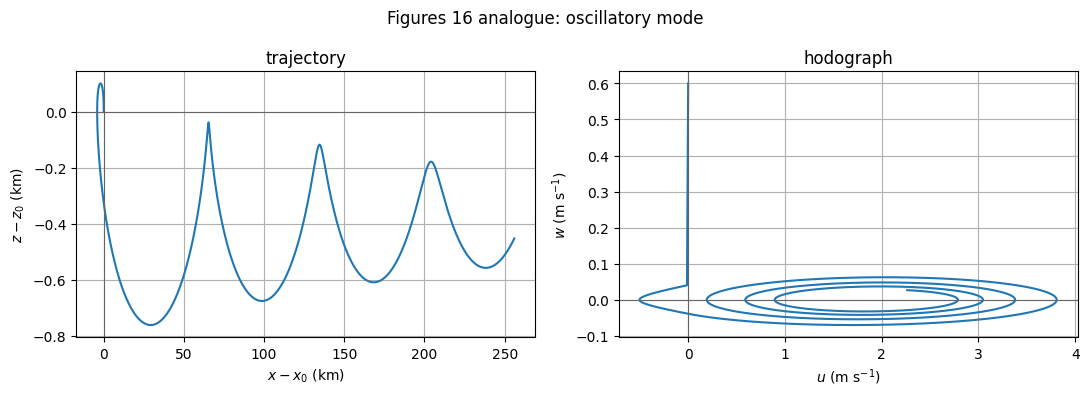

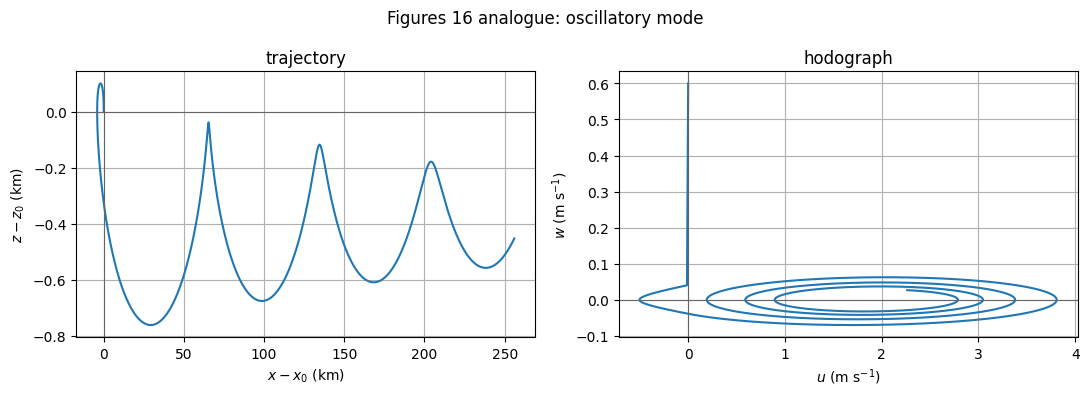

In [4]:
bp.plot_trajectory_hodograph(
    data,
    "Figures 16 analogue: oscillatory mode",
    early_hours=None,
)

## Abscissa and altitude vs time

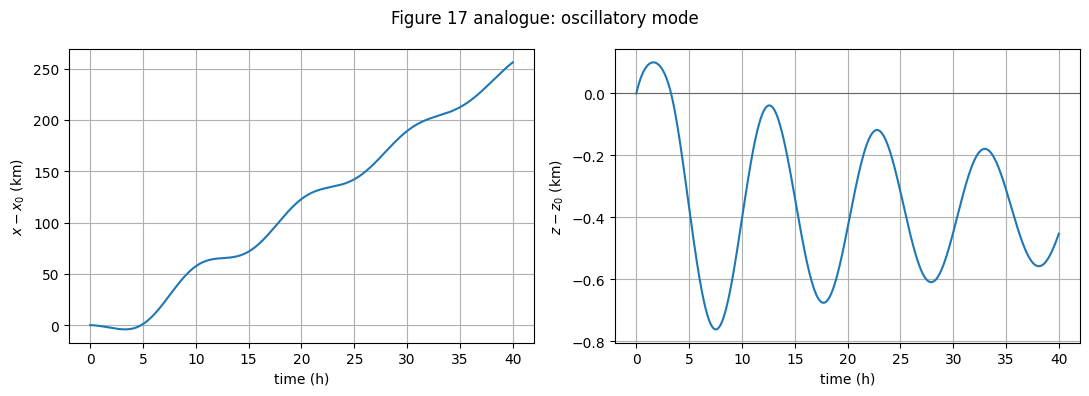

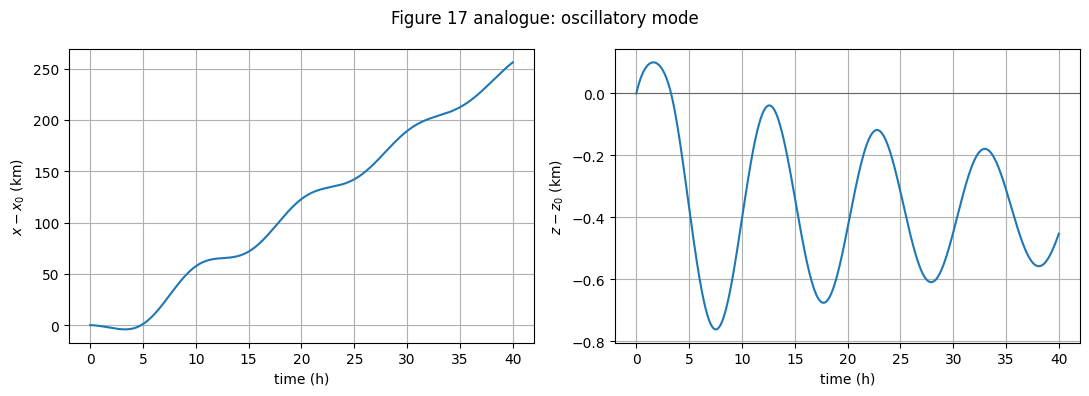

In [5]:
bp.plot_x_z(data, "Figure 17 analogue: oscillatory mode")

## Fall speed, supersaturation, radiation, driving factor

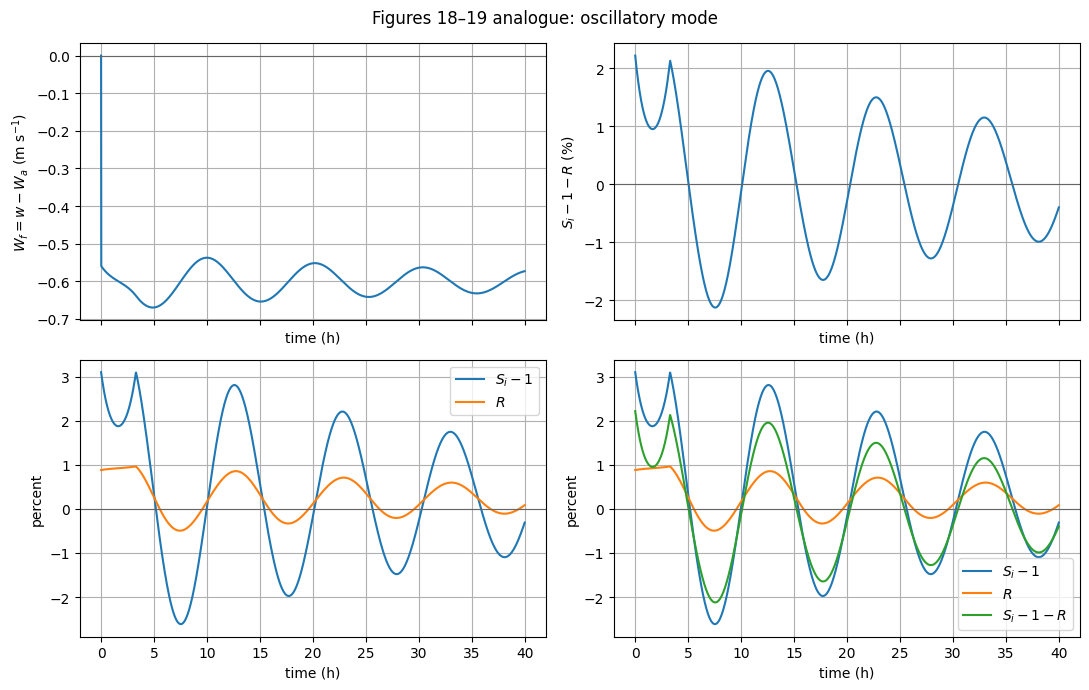

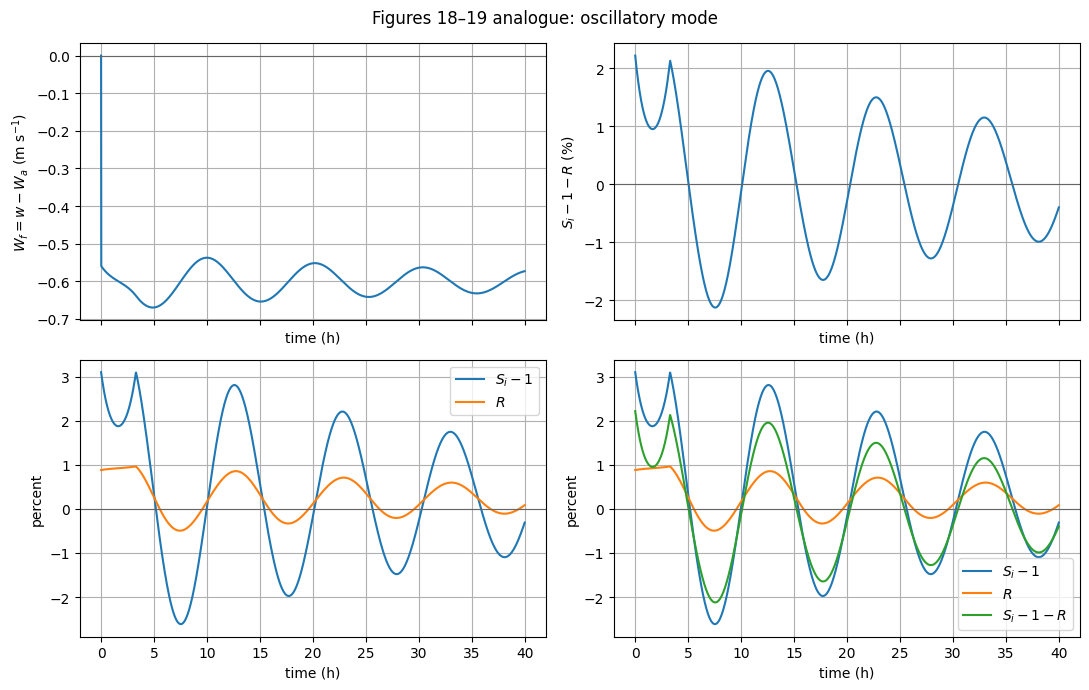

In [6]:
bp.plot_microphysics_drivers(data, "Figures 18–19 analogue: oscillatory mode")

## Mass, dimensions, equivalent diameter, viscosity

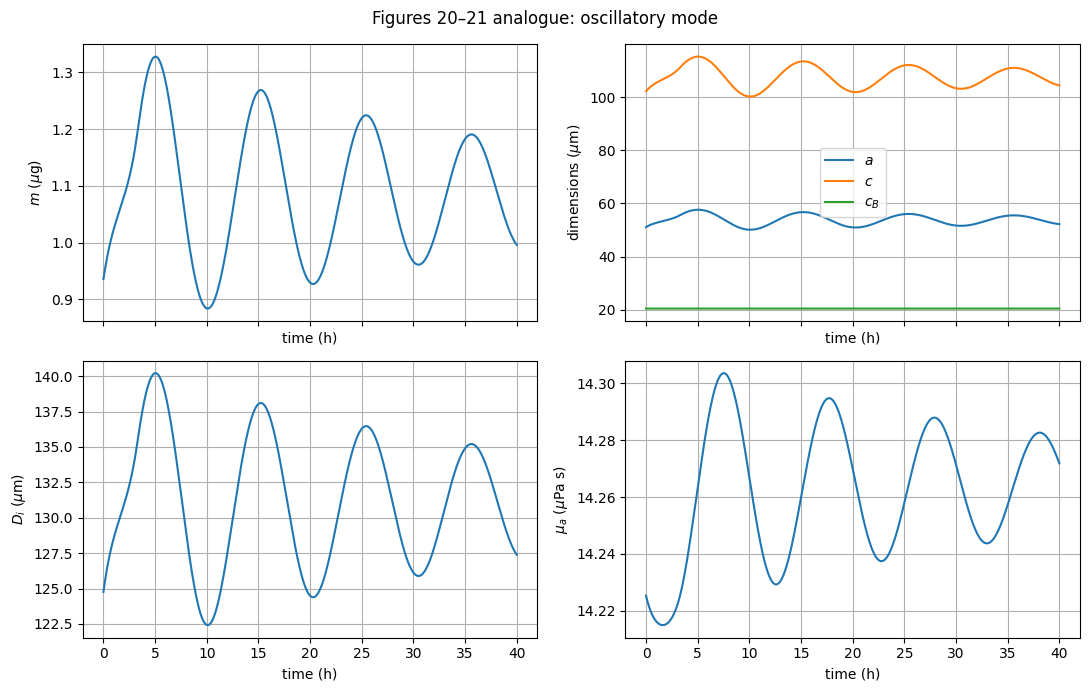

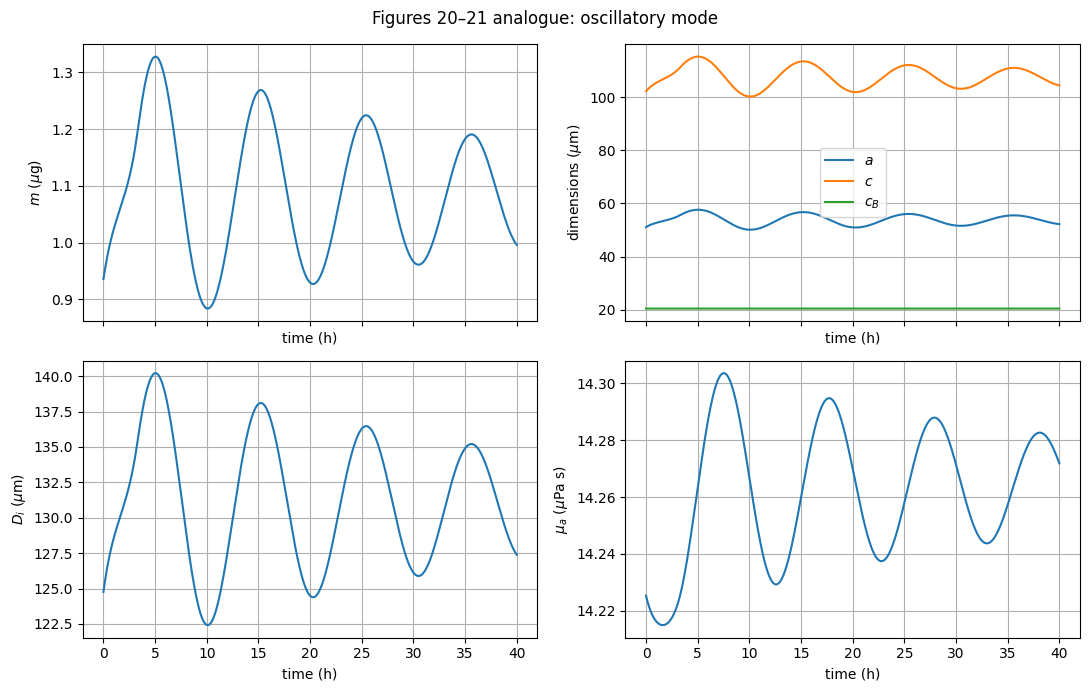

In [7]:
bp.plot_size_state(data, "Figures 20–21 analogue: oscillatory mode")

## Shape, drag, damping, temperature difference

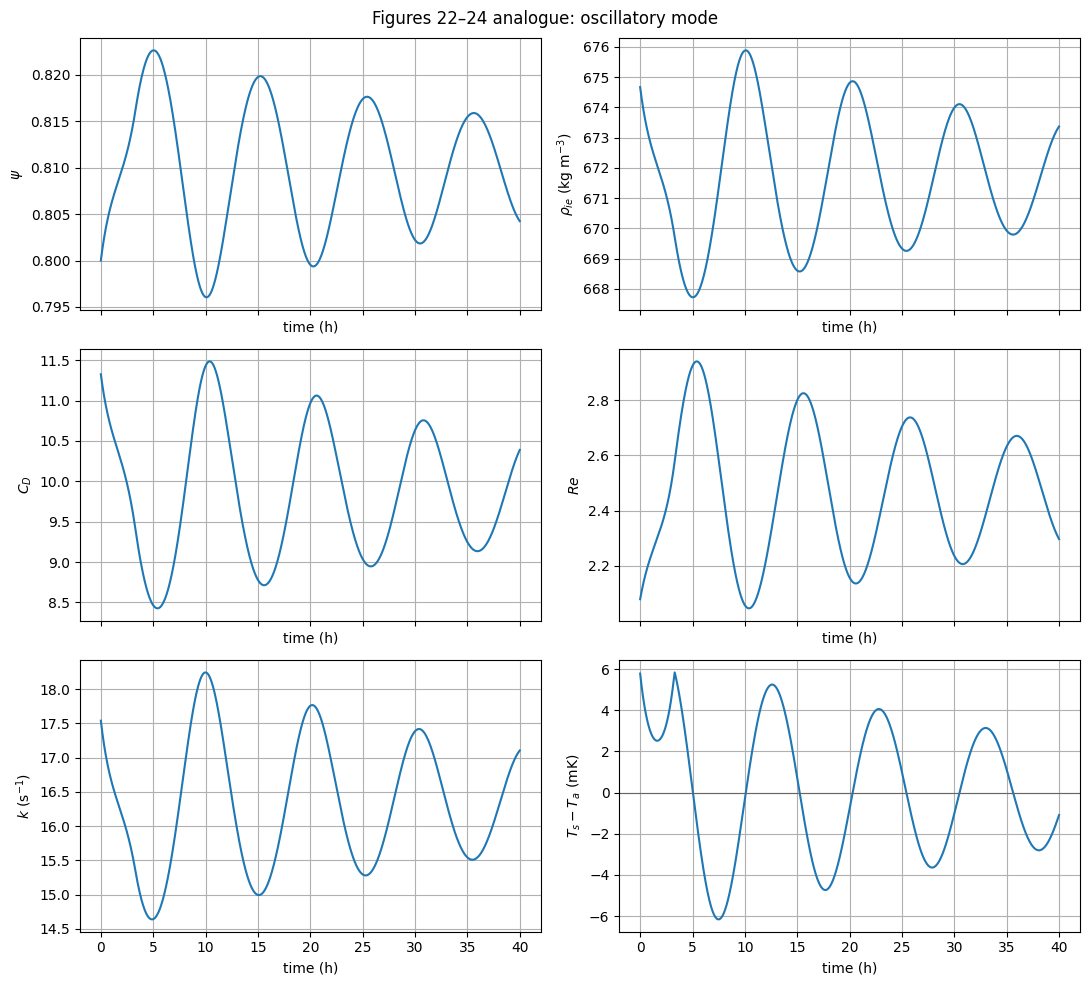

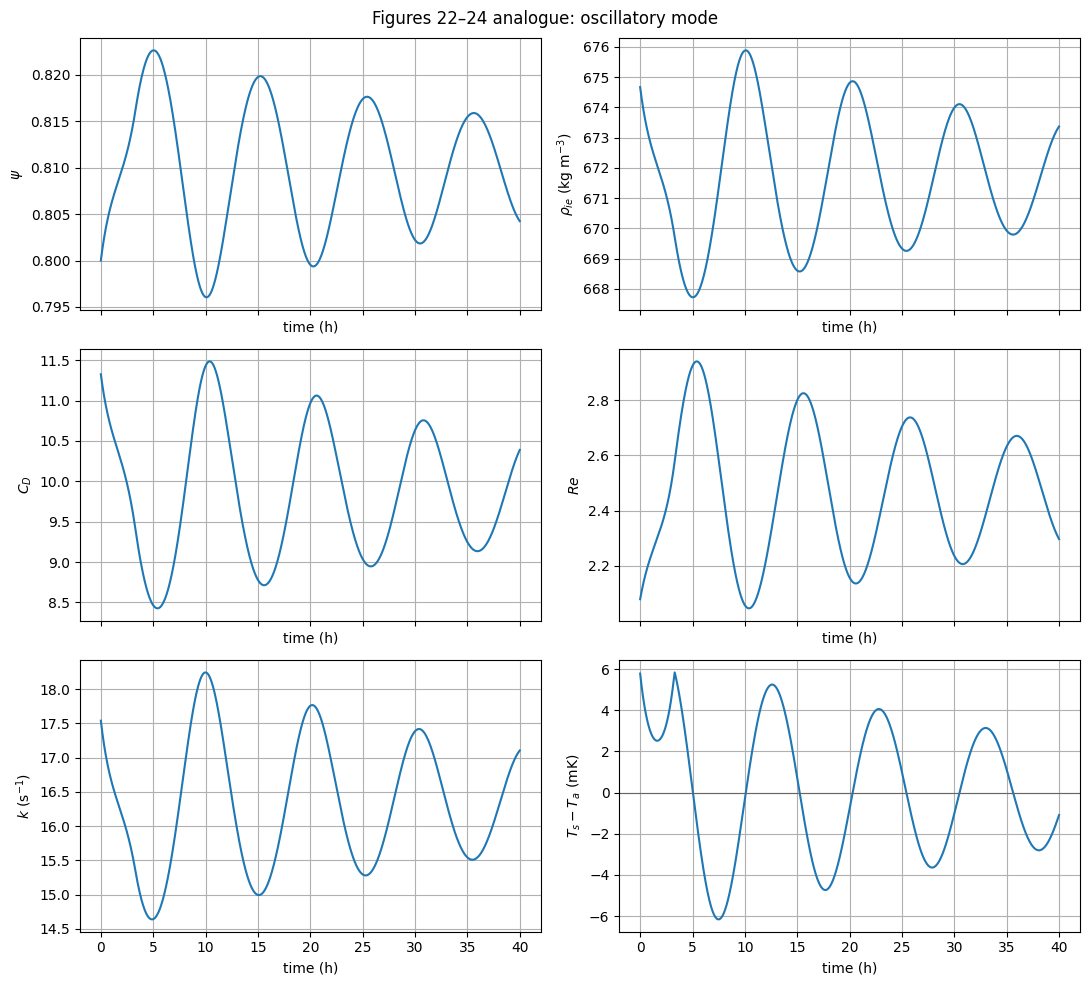

In [8]:
bp.plot_drag_state(data, "Figures 22–24 analogue: oscillatory mode")

## Reload saved numeric CSV

In [9]:
reloaded = pd.read_csv(repo / "notebooks" / "df_oscillatory_magnitudes.csv")
reloaded.head()

,t_h,x_km,z_km,u_m_s,w_m_s,m_ug,a_um,c_um,cB_um,Di_um,...,dT_mK,Siminus1_pct,R_pct,drive_pct,psi,CD,Re,x_minus_x0_km,z_minus_z0_km,Wf_m_s
0,0.000000,2.000000,10.000000,0.000000,0.600000,0.935543,51.100000,102.200000,20.44,124.764911,...,5.784852,3.103942,0.883524,2.220418,0.800000,11.326126,2.078799,0.000000,0.000000,0.000000
1,0.016667,1.999625,10.002469,-0.012334,0.040283,0.937582,51.138255,102.276511,20.44,124.855484,...,5.705692,3.073859,0.884207,2.189652,0.800150,11.309472,2.082308,-0.000375,0.002469,-0.559717
2,0.033333,1.998525,10.004865,-0.024315,0.039592,0.939595,51.175970,102.351940,20.44,124.944777,...,5.628842,3.044660,0.884881,2.159779,0.800297,11.293050,2.085779,-0.001475,0.004865,-0.560408
3,0.050000,1.996712,10.007220,-0.036090,0.038910,0.941583,51.213151,102.426302,20.44,125.032806,...,5.553283,3.015961,0.885545,2.130416,0.800442,11.276894,2.089205,-0.003288,0.007220,-0.561090
4,0.066667,1.994198,10.009535,-0.047662,0.038237,0.943545,51.249809,102.499618,20.44,125.119597,...,5.478998,2.987755,0.886200,2.101555,0.800585,11.261000,2.092587,-0.005802,0.009535,-0.561763
